In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import scanpy as sc
import os
from dotenv import load_dotenv; load_dotenv()
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.cm as mcm
from itertools import product
import ast

from utils import preprocessing


In [2]:
slidetags = sc.read_h5ad("/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/all_lib_adata_zoned_ct-cured.h5ad", backed="r")
nucseq = sc.read_h5ad("/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/adatas/Striatum/Striatum_combined_QC_mmc_ct-cured_zoned.h5ad", backed="r"    )

In [3]:
# Same gene format
nucseq.var.index = nucseq.var["gene_symbol"]
slidetags.var.index = slidetags.var["gene_symbol"]

In [22]:
mapping_zone = {
    #(ct_for_deg, zone_label, file used for mapping, meker gene list in .env)
    "Matrix_D1": ("Matrix_D1", "zone", "STR_D1_Matrix_MSN.h5ad", "ZONE_MARKERS_D1_MATRIX"),
    "Astrocyte": ("Astrocytes", "zone_4", "Astrocyte_4_zones.h5ad", "ZONE_MARKERS_ASTROCYTE"),

}

CELL_TYPE_TO_CHECK = "Matrix_D1"
ZONE_COL = mapping_zone[CELL_TYPE_TO_CHECK][1]
FILE_FOR_MAPPING = mapping_zone[CELL_TYPE_TO_CHECK][2]
MARKER_GENES = mapping_zone[CELL_TYPE_TO_CHECK][3]

# Gene markers: D1 Matrix

In [5]:
CONDITION_COL = "condition"  # <-- adjust
HEALTHY_LABEL = "Ctrl"       # <-- adjust
DISEASE_LABEL = "XDP"        # <-- adjust

In [8]:
nucseq.obs["ct_for_deg"].value_counts()

ct_for_deg
Oligodendrocyte      122867
Astrocyte             27715
-Low_quality          14435
Matrix_D2             11745
Matrix_D1             11037
Microglia              9868
non-MSN                8335
OPC                    7219
Patch_D1               4098
Patch_D2               3171
eMSN_D1D2              2830
Ependymal              1451
eMSN_NUDAP             1359
-TAFA1                 1005
eMSN_StrioMat           885
Macrophages             761
Endothelial_BBB         711
COP                     440
Lymphocyte              415
Pericytes               334
Fibroblasts             230
SmoothMuscleCells        88
Monocytes                81
Name: count, dtype: int64

In [8]:
slidetags.obs["ct_for_deg"].value_counts()

ct_for_deg
Oligodendrocyte         246358
-Low_quality             47454
Astrocyte                44987
non-MSN                  35961
Microglia                27673
Matrix_D2                24113
Matrix_D1                21964
OPC                      13476
eMSN_NUDAP               13025
eMSN_D1D2                 7567
Patch_D1                  6813
-TAFA1                    5594
Patch_D2                  4929
OT_D1_ICj                 4879
Endothelial_BBB           4775
-Mito_cluster_matrix      4340
Pericytes                 3365
Claustrum                 3023
Ependymal                 2844
eMSN_StrioMat             2640
-Mito_cluster_Astro       1814
-Mito_cluster_patch       1741
Tcells                    1415
ImAstro                   1327
Fibroblasts               1235
Macrophages               1153
L6                        1047
-Mito_cluster_D1D2         727
nan                        617
SmoothMuscleCells          374
COP                        281
Bcells                     1

In [9]:
# Subset to current cell type

mask = (
    (nucseq.obs["ct_for_deg"] == CELL_TYPE_TO_CHECK) &# only QC cells
    (nucseq.obs[ZONE_COL].notna())
)
nucseq_d1_matrix = nucseq[mask].to_memory().copy()
print(nucseq_d1_matrix)

mask = (
    (slidetags.obs["ct_for_deg"] == CELL_TYPE_TO_CHECK) &# only QC cells
    (slidetags.obs[ZONE_COL].notna()) # only QC cells
)
slidetag_d1_matrix = slidetags[mask].to_memory().copy()
print(slidetag_d1_matrix)

AnnData object with n_obs × n_vars = 10992 × 38601
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'barcode', 'bcl', 'rna_index', 'library', 'library__barcode', 'frac_mito', 'mol_info_nUMI', 'mol_info_nRead', 'frac_intronic', 'donor_id', 'vireo_prob_max', 'vireo_prob_doublet', 'vireo_n_vars', 'vireo_best_singlet', 'vireo_best_doublet', 'vireo_doublet_logLikRatio', 'dropsift_frac_contamination', 'dropsift_training_label_is_cell', 'dropsift_empty_gene_module_score', 'dropsift_is_cell', 'dropsift_is_cell_prob', 'cell_class', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'tissue', 'broad_original_cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'brain_bank', 'cohort', 'condition', 'sex', 'age_of_ons

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 21964 × 37464
    obs: 'x', 'y', 'pct_intronic', 'dbscan_clusters', 'dbscan_score', 'has_spatial', 'sample', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Neighborhood_aggregate_probability', 'Class_name', 'Class_bootstrapping_probability', 'Class_aggregate_probability', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Subclass_aggregate_probability', 'Group_name', 'Group_bootstrapping_probability', 'Group_aggregate_probability', 'Cluster_label', 'Cluster_name', 'Cluster_alias', 'Cluster_bootstrapping_probability', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_id', 'donor_number', 'donor_id', 'condition', 'sex', 'age_at_onset', 'age_at_death', 'bcl', 'library', 'Sorted', 'mapping_coupling_for_zoning', 'zone', 'zone_probability', 'mapping_coupling_for_zoning_4_zones', 'zone_4', 'zone_4_probability', 'leiden_0.1_all_ce

In [10]:
slidetag_d1_matrix = slidetag_d1_matrix[:, ~slidetag_d1_matrix.var_names.duplicated()].copy()

In [11]:
# Read reference
ref_d1_matrix_zoning = sc.read_h5ad(f"/home/gdallagl/myworkdir/XDP/data/STR_zonation_references_h5ad/{FILE_FOR_MAPPING}").copy()
# change the name of the col that have the zones
ref_d1_matrix_zoning.obs[ZONE_COL] = ref_d1_matrix_zoning.obs["Final_Zone_Assignments_No_Smooth"]#"Final_Zone_Assignments_No_Smooth"]
# all healthy
ref_d1_matrix_zoning.obs[CONDITION_COL] = HEALTHY_LABEL

In [12]:
nucseq_d1_matrix.obs["condition"].value_counts()
slidetag_d1_matrix.obs["condition"].value_counts()

condition
diseased     16993
healthy       3209
diseased      1762
Name: count, dtype: int64

In [13]:
# ── SET raw counts in X ───────────────────────────────────────────────────────
nucseq_d1_matrix.X        = nucseq_d1_matrix.layers["counts"].copy()
slidetag_d1_matrix.X      = slidetag_d1_matrix.layers["counts"].copy()
ref_d1_matrix_zoning.layers["counts"] = ref_d1_matrix_zoning.X.copy() # if not already in layers, set it
# ref already raw

# ── TAG modality ──────────────────────────────────────────────────────────────
nucseq_d1_matrix.obs["modality"]     = "NucSeq"
slidetag_d1_matrix.obs["modality"]   = "Slidetags"
ref_d1_matrix_zoning.obs["modality"] = "Ref"

# ── ALIGN var_names to gene symbols ──────────────────────────────────────────
# nucseq_d1_matrix --< var index alredy gene symbols
# slidetag_d1_matrix --< var index alredy gene symbols
# ref_d1_matrix_zoning --< var index alredy gene symbols

# nucseq_d1_matrix.var
# slidetag_d1_matrix.var
# ref_d1_matrix_zoning.var

# ──HAVE SAME CONDITIONS FORMAT ──────────────────────────────────────────
slidetag_d1_matrix.obs[CONDITION_COL] = slidetag_d1_matrix.obs["condition"]
slidetag_d1_matrix.obs[CONDITION_COL] = slidetag_d1_matrix.obs[CONDITION_COL].astype(str).map(
    {"healthy": HEALTHY_LABEL, "diseased": DISEASE_LABEL}
).astype("category")

nucseq_d1_matrix.obs[CONDITION_COL] = nucseq_d1_matrix.obs["condition"]
nucseq_d1_matrix.obs[CONDITION_COL] = nucseq_d1_matrix.obs[CONDITION_COL].astype(str).map(
    {"Control": HEALTHY_LABEL, "XDP": DISEASE_LABEL}
).astype("category")

# ref all healhty alredy done

# ── GENE INTERSECTION across all 3 ───────────────────────────────────────────
common_genes = list(
    set(nucseq_d1_matrix.var_names)
    & set(slidetag_d1_matrix.var_names)
    & set(ref_d1_matrix_zoning.var_names)
)
print(f"Common genes (3-way): {len(common_genes)}")
nucseq_d1_matrix    = nucseq_d1_matrix[:, common_genes].copy()
slidetag_d1_matrix  = slidetag_d1_matrix[:, common_genes].copy()
ref_d1_matrix_zoning = ref_d1_matrix_zoning[:, common_genes].copy()

# ── VERIFY ────────────────────────────────────────────────────────────────────
for name, adata in [("NucSeq", nucseq_d1_matrix), ("Slidetags", slidetag_d1_matrix), ("Ref", ref_d1_matrix_zoning)]:
    print(f"\n{name}: {adata.n_obs} cells | condition: {adata.obs[CONDITION_COL].unique().tolist()} | zones: {sorted(adata.obs[ZONE_COL].dropna().unique().tolist())}")
    print(f"  - condition distribution:\n{adata.obs[CONDITION_COL].value_counts()}")

Common genes (3-way): 34736

NucSeq: 10992 cells | condition: ['XDP', 'Ctrl'] | zones: ['1', '2', '3', '4', '5', '6']
  - condition distribution:
condition
Ctrl    7179
XDP     3813
Name: count, dtype: int64

Slidetags: 21964 cells | condition: ['XDP', nan, 'Ctrl'] | zones: ['1', '2', '3', '4', '5', '6']
  - condition distribution:
condition
XDP     16993
Ctrl     3209
Name: count, dtype: int64

Ref: 46960 cells | condition: ['Ctrl'] | zones: ['1', '2', '3', '4', '5', '6']
  - condition distribution:
condition
Ctrl    46960
Name: count, dtype: int64


In [32]:
zone_markers_dict = ast.literal_eval(os.getenv(MARKER_GENES))
all_markers = [g for genes in zone_markers_dict.values() for g in genes]
gene_to_zone = {g: z for z, genes in zone_markers_dict.items() for g in genes}

gene_to_zone

{'WLS': '1',
 'KEL': '1',
 'STRIT1': '1',
 'LINC00958': '1',
 'ENSG00000259255': '2',
 'ENSG00000258426': '2',
 'HTR2A': '3',
 'AMIGO2': '3',
 'ENSG00000258181': '3',
 'ENSG00000287925': '4',
 'TIMP2': '4',
 'COL21A1': '4',
 'BAIAP3': '4',
 'SLC5A8': '5',
 'ENSG00000287922': '5',
 'RXFP2': '6',
 'LINC02045': '6'}

In [24]:
# ── NORMALIZE EACH DATASET INDEPENDENTLY ─────────────────────────────────────
datasets = {"NucSeq": nucseq_d1_matrix, "Slidetags": slidetag_d1_matrix, "Ref": ref_d1_matrix_zoning}
for name, adata in datasets.items():
    adata.X = adata.layers["counts"].copy()
    sc.pp.normalize_total(adata, target_sum=1e4)

    adata = adata[:, [g for g in all_markers if g in adata.var_names]].copy()

    sc.pp.log1p(adata)
    adata.layers["log1p_norm"] = adata.X.copy()
    sc.pp.scale(adata)
    adata.layers["scaled"] = adata.X.copy()
    adata.X = adata.layers["counts"].copy()

    datasets[name] = adata  # ← save processed+subsetted adata back
    print(f"{name}: {adata.n_obs} cells | ...")

    print(f"{name}: {adata.n_obs} cells | condition: {adata.obs[CONDITION_COL].unique().tolist()} | zones: {sorted(adata.obs[ZONE_COL].dropna().unique().tolist())}")

NucSeq: 10992 cells | ...
NucSeq: 10992 cells | condition: ['XDP', 'Ctrl'] | zones: ['1', '2', '3', '4', '5', '6']


/home/gdallagl/.pyenv/versions/3.11.8/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/home/gdallagl/.pyenv/versions/3.11.8/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Slidetags: 21964 cells | ...
Slidetags: 21964 cells | condition: ['XDP', nan, 'Ctrl'] | zones: ['1', '2', '3', '4', '5', '6']
Ref: 46960 cells | ...
Ref: 46960 cells | condition: ['Ctrl'] | zones: ['1', '2', '3', '4', '5', '6']


/home/gdallagl/.pyenv/versions/3.11.8/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [25]:
def mean_per_condition(adata, markers, condition_col=CONDITION_COL):
    available = [g for g in markers if g in adata.var_names] # genes available in the adata
    expr = sc.get.obs_df(adata, keys=available, layer="scaled") # make layer a df
    expr[condition_col] = adata.obs[condition_col].astype(str).values # add condition col to the df for each cell
    return expr.groupby(condition_col)[available].mean().T  # genes x condition

df_nucseq    = mean_per_condition(datasets["NucSeq"],    all_markers)
df_slidetags = mean_per_condition(datasets["Slidetags"], all_markers)
df_ref       = mean_per_condition(datasets["Ref"],       all_markers)

rows = []
for gene in all_markers:
    row = {"gene": gene, "marker_zone": gene_to_zone[gene]}
    for cond in [HEALTHY_LABEL, DISEASE_LABEL]:
        for name, df in [("nucseq", df_nucseq), ("slidetags", df_slidetags), ("ref", df_ref)]:
            col = f"{name}_{cond}"
            row[col] = df.loc[gene, cond] if (gene in df.index and cond in df.columns) else np.nan
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index("gene")

# drop gene and dataset with nan
summary_df = summary_df.drop(columns=["ref_XDP"])
#summary_df = summary_df.dropna(axis=1, how="any")
#summary_df = summary_df.dropna(axis=1, how="any")

summary_df


,marker_zone,nucseq_Ctrl,slidetags_Ctrl,ref_Ctrl,nucseq_XDP,slidetags_XDP
gene,,,,,,
WLS,1,0.056242,0.265727,-7.940482e-17,-0.105891,-0.044327
KEL,1,0.038320,0.081983,-4.847060e-17,-0.072147,-0.005595
STRIT1,1,0.076497,0.490957,7.104032e-17,-0.144026,-0.082870
LINC00958,1,0.101296,0.478154,1.252074e-17,-0.190717,-0.089132
ENSG00000259255,2,0.065366,0.221571,1.780471e-17,-0.123070,-0.037857
ENSG00000258426,2,NaN,NaN,NaN,NaN,NaN
HTR2A,3,0.044558,-0.072319,-5.886712e-17,-0.083893,0.023406
AMIGO2,3,-0.012763,-0.074842,-3.261517e-17,0.024029,0.014878
ENSG00000258181,3,-0.021525,-0.112482,8.913051e-17,0.040527,0.016436


# Plot

**Preprocessing (independent per dataset):**
1. `normalize_total` (10k) → `log1p` — library-size correction on all genes before subsetting
2. Subset to marker genes only
3. Mean log1p expression computed per **zone × condition** group
4. Scale

**Metric:** mean scaled (z-score) expression per zone × dataset × condition.
Scaled independently per dataset → values represent deviation from that dataset's own mean (0 = average, positive = above average).
This removes technology bias (NucSeq nuclear RNA vs SlideTags total RNA vs Ref) and highlights zone gradients.

**How to read:**
- Red = above dataset mean, Blue = below
- A valid marker should show **red in its marker zone** consistently across datasets
- NaN columns (missing condition/dataset combos) are dropped


In [16]:
datasets.items()#["NucSeq"].obs[ZONE_COL].astype(str)

dict_items([('NucSeq', AnnData object with n_obs × n_vars = 27678 × 15
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'barcode', 'bcl', 'rna_index', 'library', 'library__barcode', 'frac_mito', 'mol_info_nUMI', 'mol_info_nRead', 'frac_intronic', 'donor_id', 'vireo_prob_max', 'vireo_prob_doublet', 'vireo_n_vars', 'vireo_best_singlet', 'vireo_best_doublet', 'vireo_doublet_logLikRatio', 'dropsift_frac_contamination', 'dropsift_training_label_is_cell', 'dropsift_empty_gene_module_score', 'dropsift_is_cell', 'dropsift_is_cell_prob', 'cell_class', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'tissue', 'broad_original_cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'brain_bank', 'cohort', 'condition'

In [31]:
mapping


{'1': 'V', '2': 'D', '3': 'C', '4': 'P'}

In [33]:
mapping = {
    "1": "V",
    "2": "D",
    "3": "C",
    "4": "P"
}

if ZONE_COL == "zone_4":

    for key, a in datasets.items():
        a.obs[ZONE_COL] = a.obs[ZONE_COL].astype(str).map(mapping)

    display(adata.obs[ZONE_COL])

    # chameg dict too
    gene_to_zone = {k: mapping.get(str(v), v) for k, v in gene_to_zone.items()}

gene_to_zone

{'WLS': '1',
 'KEL': '1',
 'STRIT1': '1',
 'LINC00958': '1',
 'ENSG00000259255': '2',
 'ENSG00000258426': '2',
 'HTR2A': '3',
 'AMIGO2': '3',
 'ENSG00000258181': '3',
 'ENSG00000287925': '4',
 'TIMP2': '4',
 'COL21A1': '4',
 'BAIAP3': '4',
 'SLC5A8': '5',
 'ENSG00000287922': '5',
 'RXFP2': '6',
 'LINC02045': '6'}

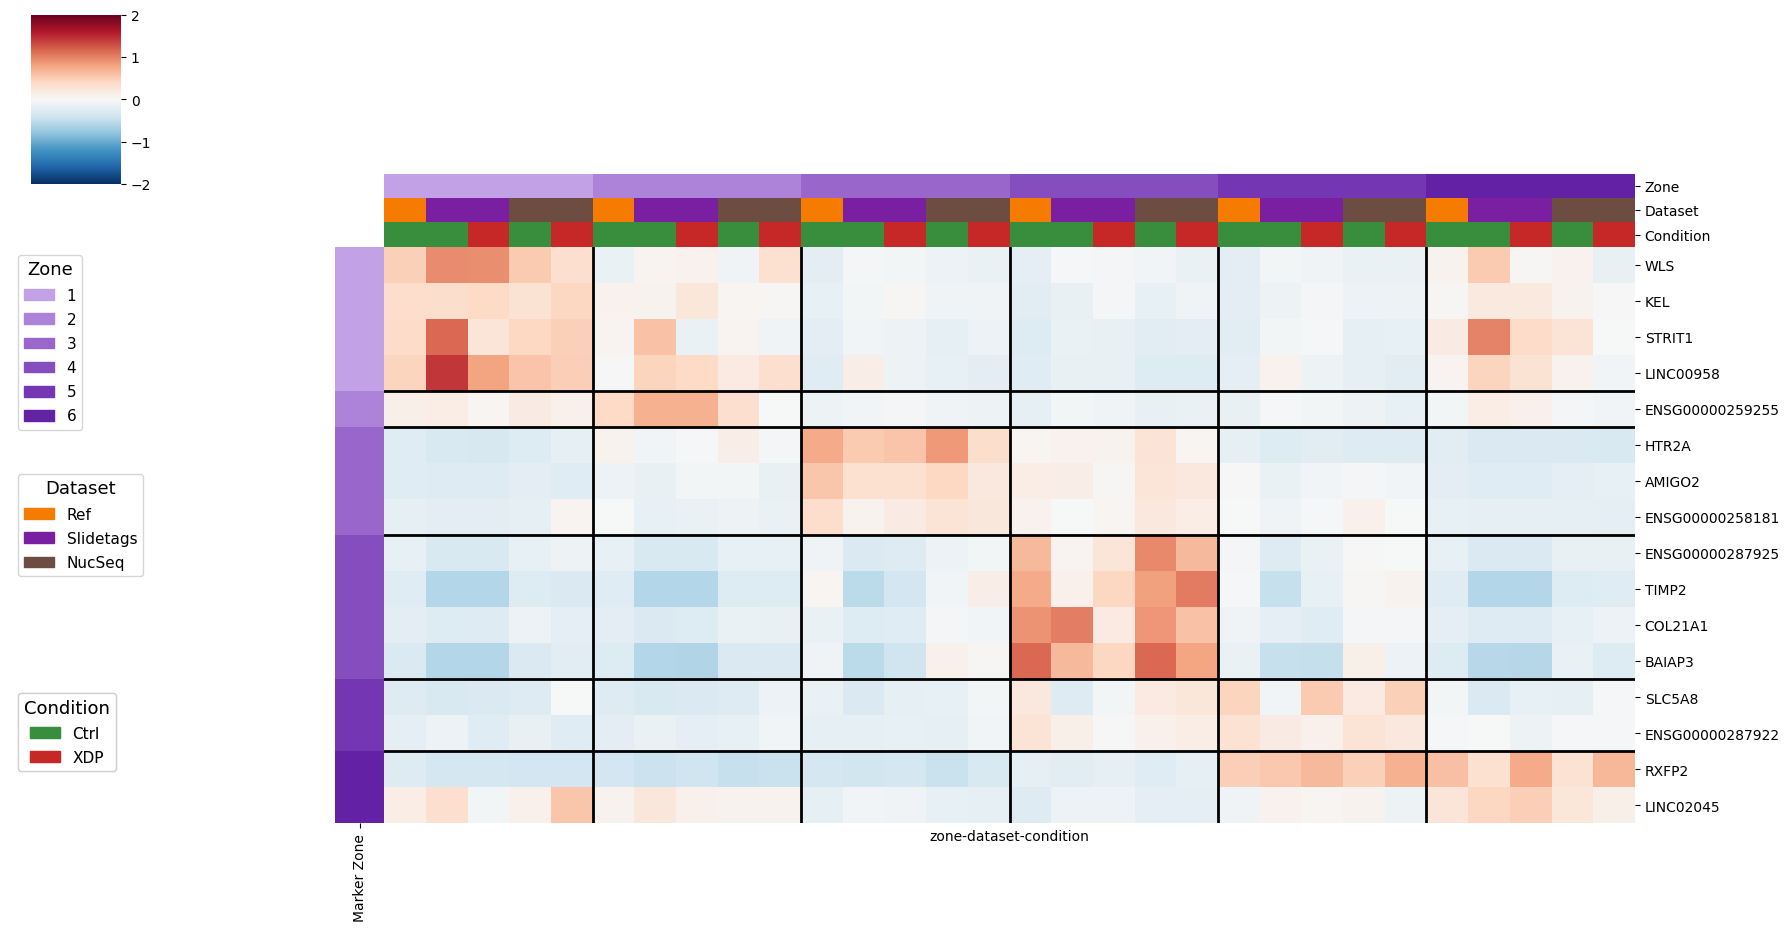

In [34]:
import matplotlib.colors as mcolors

zones         = sorted(set(z for adata in datasets.values() for z in adata.obs[ZONE_COL].astype(str).unique()))
# ── Ref first, Slidetags second, then the rest ────────────────────────────────
dataset_names = ["Ref", "Slidetags"] + [d for d in datasets.keys() if d not in ("Ref", "Slidetags")]
conditions    = [HEALTHY_LABEL, DISEASE_LABEL]

# ── PALETTES ──────────────────────────────────────────────────────────────────
# Zones → shades of purple (avoids red/green used by heatmap & condition)
def _zone_shades(n, hue=0.75):   # 0.75 = purple
    if n == 1:
        return [mcolors.hsv_to_rgb((hue, 0.55, 0.75))]
    return [
        mcolors.hsv_to_rgb((hue, 0.30 + 0.50 * i / (n - 1),
                                  0.90 - 0.25 * i / (n - 1)))
        for i in range(n)
    ]

zone_pal  = dict(zip(zones, _zone_shades(len(zones))))

# Datasets → Orange / Violet / Brown  (Ref always orange = most prominent)
ds_pal    = {
    "Ref"      : "#F57C00",   # Orange
    "Slidetags": "#7B1FA2",   # Violet
    "NucSeq"   : "#6D4C41",   # Brown
}

# Condition → Green (Control) / Red (XDP)
cond_pal  = {HEALTHY_LABEL: "#388E3C", DISEASE_LABEL: "#C62828"}

ordered_idx = pd.MultiIndex.from_tuples(
    [(z, ds, c) for z in zones for ds in dataset_names for c in conditions],
    names=["zone", "dataset", "condition"]
)

records = []
for ds_name, adata in datasets.items():
    available = [g for g in all_markers if g in adata.var_names]
    expr = sc.get.obs_df(adata, keys=available, layer="scaled")
    expr["zone"]      = adata.obs[ZONE_COL].astype(str).values
    expr["condition"] = adata.obs[CONDITION_COL].astype(str).values
    means = expr.groupby(["zone", "condition"])[available].mean()
    means.index = pd.MultiIndex.from_tuples(
        [(z, ds_name, c) for z, c in means.index], names=["zone", "dataset", "condition"]
    )
    records.append(means)

mat_df = pd.concat(records).reindex(ordered_idx).reindex(columns=all_markers).T
mat_df = mat_df.dropna(axis=0, how="all").dropna(axis=1, how="all")
kept_genes        = mat_df.index.tolist()
kept_gene_to_zone = {g: gene_to_zone[g] for g in kept_genes}

col_meta   = mat_df.columns.to_frame(index=False)
col_colors = pd.DataFrame({
    "Zone"     : col_meta["zone"].map(zone_pal).values,
    "Dataset"  : col_meta["dataset"].map(ds_pal).values,
    "Condition": col_meta["condition"].map(cond_pal).values,
}, index=mat_df.columns)
row_colors = pd.Series(kept_gene_to_zone).reindex(kept_genes).map(zone_pal).rename("Marker Zone")

g = sns.clustermap(
    mat_df.fillna(0),
    row_cluster=False, col_cluster=False,
    col_colors=col_colors, row_colors=row_colors,
    cmap="RdBu_r", center=0, vmin=-2, vmax=2,
    figsize=(18, len(kept_genes) * 0.4 + 3),
    xticklabels=False, yticklabels=True,
)

ax    = g.ax_heatmap
x_pos = 0
for zone, grp in col_meta.groupby("zone", sort=True):
    n = len(grp)
    if x_pos > 0:
        ax.axvline(x_pos, color="black", lw=2)
    x_pos += n

for i, gene in enumerate(kept_genes[1:], 1):
    if kept_gene_to_zone[gene] != kept_gene_to_zone[kept_genes[i - 1]]:
        ax.axhline(i, color="black", lw=2)

leg_ax = g.ax_row_dendrogram
leg_ax.clear(); leg_ax.axis("off")
y = 1.0
for title, pal in [("Zone", zone_pal), ("Dataset", ds_pal), ("Condition", cond_pal)]:
    handles = [mpatches.Patch(color=c, label=k) for k, c in pal.items()]
    leg = leg_ax.legend(handles=handles, title=title, loc="upper left",
                        bbox_to_anchor=(0, y), fontsize=11, title_fontsize=13,
                        frameon=True, labelspacing=0.6)
    leg_ax.add_artist(leg)
    y -= 0.38

plt.show()

## Zone marker expression heatmap — cell counts

**Each cell = number of cells in that case**


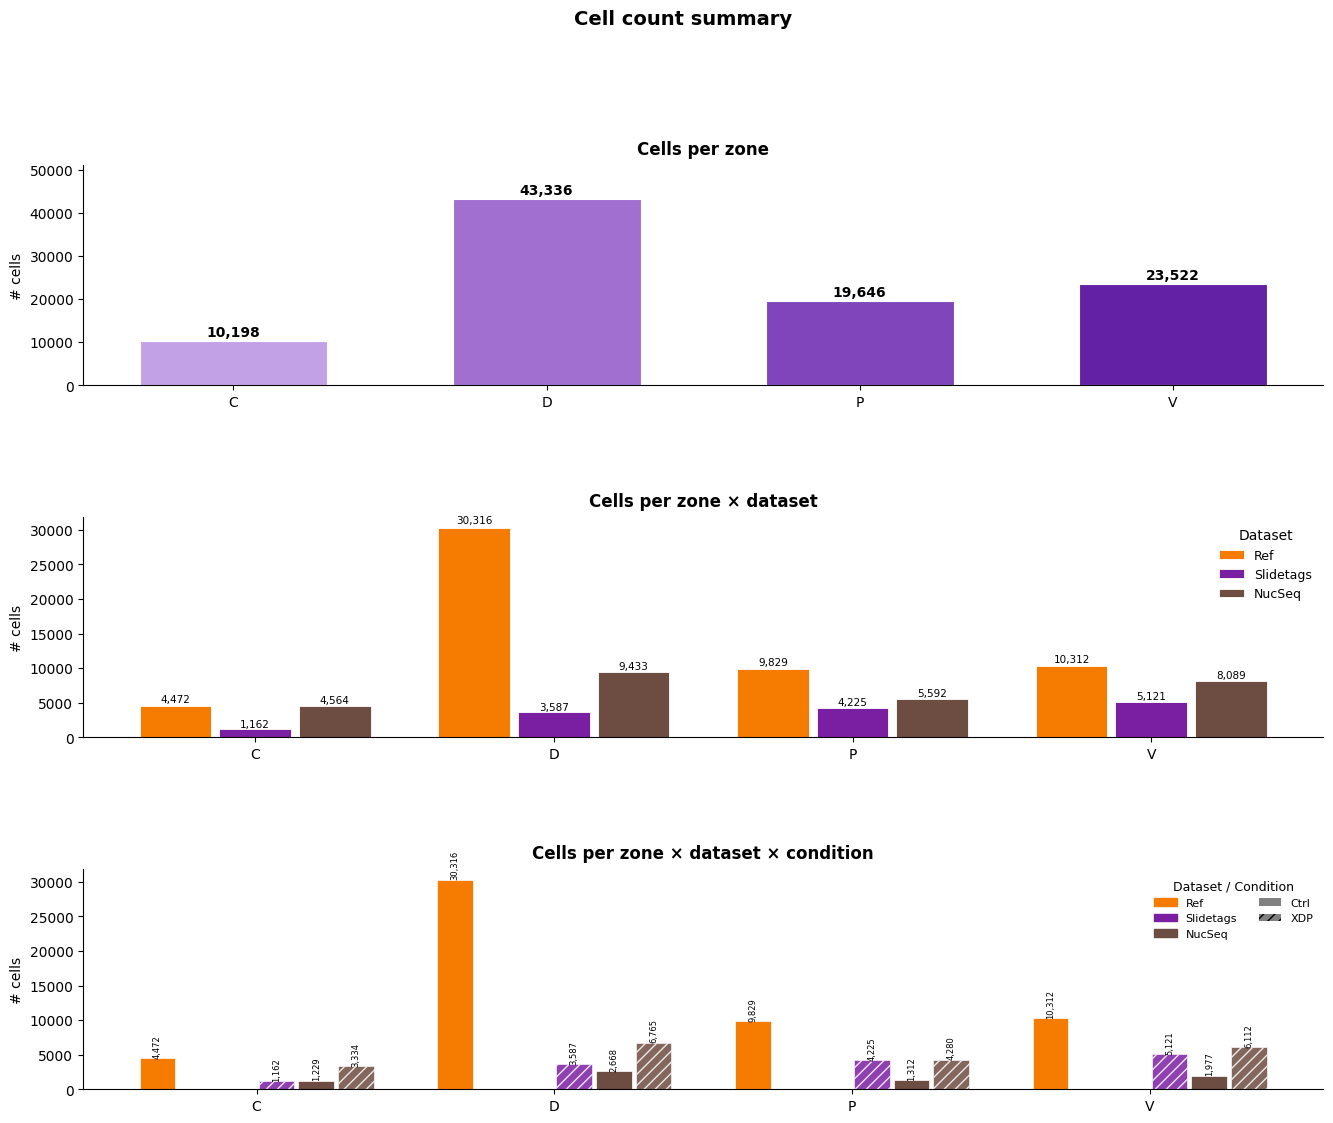

In [19]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), gridspec_kw={"hspace": 0.6})

# ── build master obs table ────────────────────────────────────────────────────
all_obs = []
for ds_name, adata in datasets.items():
    tmp = adata.obs[[ZONE_COL, CONDITION_COL]].copy()
    tmp.columns = ["zone", "condition"]
    tmp["dataset"] = ds_name
    all_obs.append(tmp)
all_obs = pd.concat(all_obs)

# ── 1. by Zone ────────────────────────────────────────────────────────────────
ax = axes[0]
counts = all_obs.groupby("zone").size().reindex(zones)
bars = ax.bar(zones, counts.values,
              color=[zone_pal[z] for z in zones],
              edgecolor="white", linewidth=0.8, width=0.6)
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + counts.max() * 0.01,
            f"{int(v):,}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_title("Cells per zone", fontsize=12, fontweight="bold", pad=8)
ax.set_ylabel("# cells", fontsize=10)
ax.set_ylim(0, counts.max() * 1.18)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="x", labelsize=10)

# ── 2. by Zone × Dataset ──────────────────────────────────────────────────────
ax = axes[1]
n_ds   = len(dataset_names)
x      = np.arange(len(zones))
width  = 0.8 / n_ds
for i, ds in enumerate(dataset_names):
    counts_ds = (all_obs[all_obs.dataset == ds]
                 .groupby("zone").size().reindex(zones).fillna(0))
    offset = (i - n_ds / 2 + 0.5) * width
    bars = ax.bar(x + offset, counts_ds.values,
                  width=width * 0.9,
                  color=ds_pal[ds],
                  edgecolor="white", linewidth=0.6,
                  label=ds)
    for bar, v in zip(bars, counts_ds.values):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + counts_ds.max() * 0.01,
                    f"{int(v):,}", ha="center", va="bottom", fontsize=7.5)

ax.set_title("Cells per zone × dataset", fontsize=12, fontweight="bold", pad=8)
ax.set_ylabel("# cells", fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(zones, fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(title="Dataset", fontsize=9, title_fontsize=10,
          frameon=False, loc="upper right")

# ── 3. by Zone × Dataset × Condition ─────────────────────────────────────────
ax = axes[2]
combos  = [(ds, c) for ds in dataset_names for c in conditions]
n_combos = len(combos)
width    = 0.8 / n_combos

# hatching to separate condition within same dataset colour
hatches = {HEALTHY_LABEL: "", DISEASE_LABEL: "///"}

for i, (ds, cond) in enumerate(combos):
    counts_dc = (all_obs[(all_obs.dataset == ds) & (all_obs.condition == cond)]
                 .groupby("zone").size().reindex(zones).fillna(0))
    offset = (i - n_combos / 2 + 0.5) * width
    bars = ax.bar(x + offset, counts_dc.values,
                  width=width * 0.9,
                  color=ds_pal[ds],
                  hatch=hatches[cond],
                  edgecolor="white", linewidth=0.5,
                  alpha=0.85 if cond == DISEASE_LABEL else 1.0)
    for bar, v in zip(bars, counts_dc.values):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 5,
                    f"{int(v):,}", ha="center", va="bottom",
                    fontsize=6, rotation=90)

ax.set_title("Cells per zone × dataset × condition", fontsize=12, fontweight="bold", pad=8)
ax.set_ylabel("# cells", fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(zones, fontsize=10)
ax.spines[["top", "right"]].set_visible(False)

# legend: dataset colour + condition hatch
legend_handles = (
    [mpatches.Patch(color=ds_pal[ds], label=ds) for ds in dataset_names]
    + [mpatches.Patch(facecolor="grey", hatch=h, label=c)
       for c, h in hatches.items()]
)
ax.legend(handles=legend_handles, fontsize=8, frameon=False,
          loc="upper right", ncol=2, title="Dataset / Condition",
          title_fontsize=9)

plt.suptitle("Cell count summary", fontsize=14, fontweight="bold", y=1.01)
plt.show()

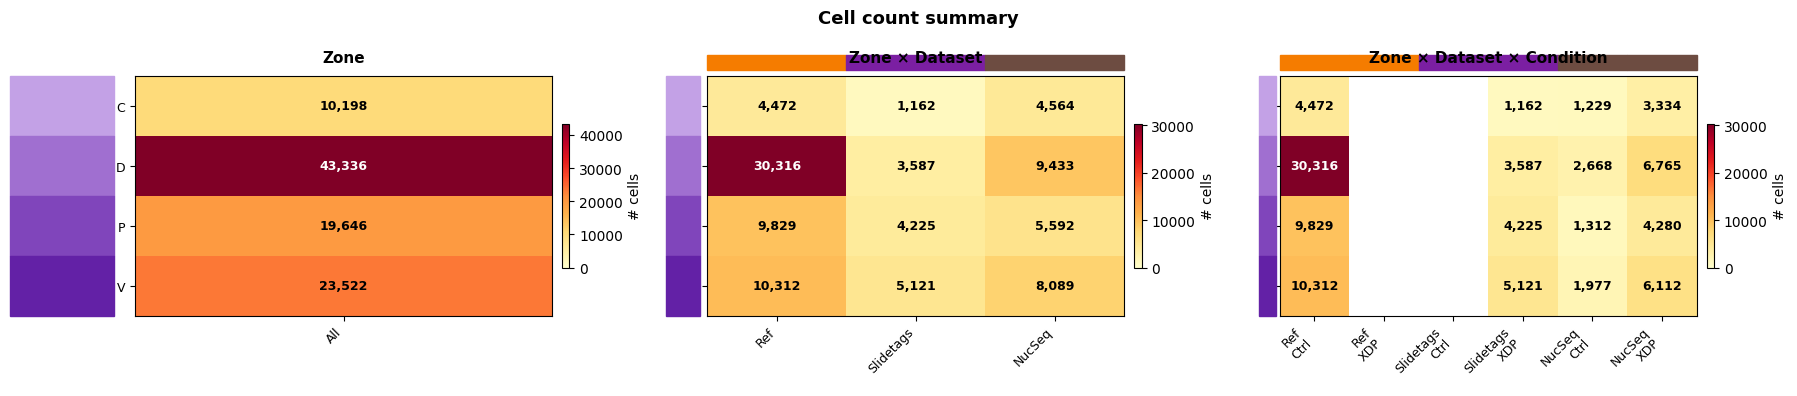

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, max(4, len(zones) * 0.5 + 2)))

# ── build master obs table ────────────────────────────────────────────────────
all_obs = []
for ds_name, adata in datasets.items():
    tmp = adata.obs[[ZONE_COL, CONDITION_COL]].copy()
    tmp.columns = ["zone", "condition"]
    tmp["dataset"] = ds_name
    all_obs.append(tmp)
all_obs = pd.concat(all_obs)

def draw_heatmap(ax, df, title, cmap="YlOrRd", fmt=","):
    """df: rows=y-axis, cols=x-axis, values=counts."""
    im = ax.imshow(df.values, aspect="auto", cmap=cmap,
                   vmin=0, vmax=np.nanmax(df.values))
    for i in range(df.shape[0]):
        for j in range(df.shape[1]):
            v = df.values[i, j]
            txt = "" if np.isnan(v) else format(int(v), fmt)
            brightness = v / (np.nanmax(df.values) + 1e-9)
            color = "white" if brightness > 0.6 else "black"
            ax.text(j, i, txt, ha="center", va="center",
                    fontsize=9, fontweight="bold", color=color)
    ax.set_xticks(range(df.shape[1]))
    ax.set_xticklabels(df.columns.tolist(), fontsize=9, rotation=45, ha="right")
    ax.set_yticks(range(df.shape[0]))
    ax.set_yticklabels(df.index.tolist(), fontsize=9)
    ax.set_title(title, fontsize=11, fontweight="bold", pad=10)
    # zone colour bar on the left y-axis
    for i, zone in enumerate(df.index):
        ax.add_patch(plt.Rectangle((-0.5 - 0.3, i - 0.5), 0.25, 1,
                                   color=zone_pal.get(zone, "grey"),
                                   clip_on=False, zorder=3))
    plt.colorbar(im, ax=ax, shrink=0.6, pad=0.02,
                 label="# cells", format="%d")

# ── 1. Zone only (single column) ─────────────────────────────────────────────
counts_z = all_obs.groupby("zone").size().reindex(zones).to_frame("All")
draw_heatmap(axes[0], counts_z, "Zone")

# ── 2. Zone × Dataset ─────────────────────────────────────────────────────────
counts_zd = (all_obs.groupby(["zone", "dataset"]).size()
             .unstack("dataset").reindex(index=zones, columns=dataset_names))
draw_heatmap(axes[1], counts_zd, "Zone × Dataset")

# ── 3. Zone × Dataset × Condition ────────────────────────────────────────────
counts_zdc = (all_obs.groupby(["zone", "dataset", "condition"]).size()
              .unstack(["dataset", "condition"])
              .reindex(index=zones,
                       columns=pd.MultiIndex.from_tuples(
                           [(ds, c) for ds in dataset_names for c in conditions])))
counts_zdc.columns = [f"{ds}\n{c}" for ds, c in counts_zdc.columns]
draw_heatmap(axes[2], counts_zdc, "Zone × Dataset × Condition")

# ── dataset colour band on top of panels 2 & 3 ───────────────────────────────
for ax, cols in [(axes[1], dataset_names),
                 (axes[2], [ds for ds in dataset_names for _ in conditions])]:
    for j, label in enumerate(cols):
        ds = label.split("\n")[0]
        ax.add_patch(plt.Rectangle((j - 0.5, -0.5 - 0.35),
                                   1, 0.25,
                                   color=ds_pal.get(ds, "grey"),
                                   clip_on=False, zorder=3))

plt.suptitle("Cell count summary", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Zone porbabilty

NameError: name 'prob_obs' is not defined

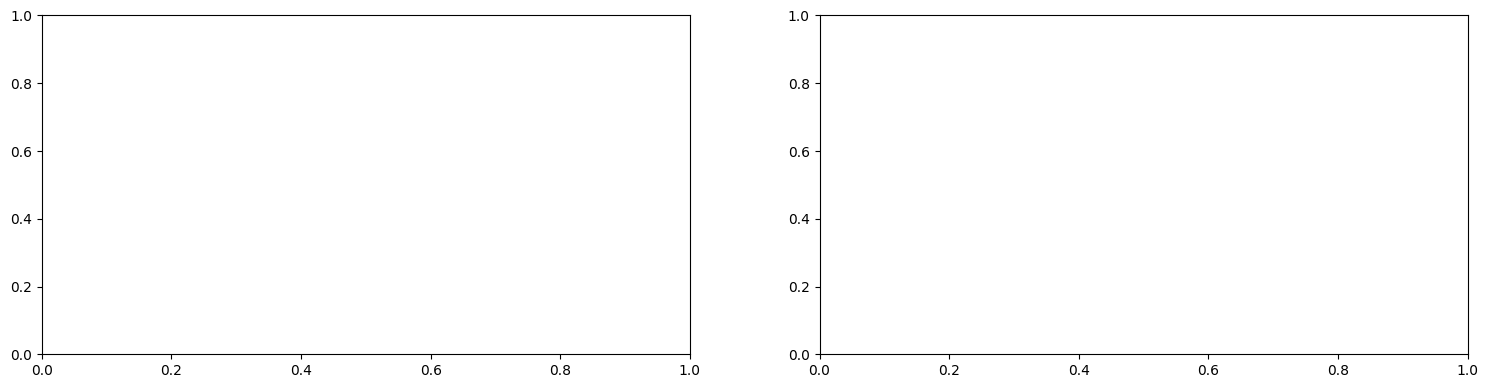

In [21]:
fig, axes = plt.subplots(1, 2, figsize=((len(combos) * 1.2 + 2) * 2, len(zones) * 0.6 + 2))

# build mean, std, CV matrices
prob_mean = pd.DataFrame(index=zones, columns=combos, dtype=float)
prob_std  = pd.DataFrame(index=zones, columns=combos, dtype=float)
prob_cv   = pd.DataFrame(index=zones, columns=combos, dtype=float)

for (ds, c) in combos:
    grp = prob_obs[(prob_obs.dataset == ds) & (prob_obs.condition == c)]
    g   = grp.groupby("zone")["prob"]
    prob_mean[(ds, c)] = g.mean().reindex(zones)
    prob_std [(ds, c)] = g.std().reindex(zones)
    prob_cv  [(ds, c)] = (g.std() / g.mean()).reindex(zones)   # CV = std/mean

col_labels = [f"{ds}\n{c}" for ds, c in combos]
for df in [prob_mean, prob_std, prob_cv]:
    df.columns = col_labels

# ── Mean ──────────────────────────────────────────────────────────────────────
sns.heatmap(prob_mean.astype(float), ax=axes[0],
            cmap="RdYlGn", vmin=0, vmax=1,
            annot=True, fmt=".2f",
            linewidths=0.5, linecolor="white",
            cbar_kws={"label": "mean probability", "shrink": 0.7})
axes[0].set_title("Mean transfer probability", fontsize=12, fontweight="bold", pad=10)
axes[0].set_xlabel(""); axes[0].set_ylabel("Zone", fontsize=10)
axes[0].tick_params(axis="x", rotation=45, labelsize=9)
axes[0].tick_params(axis="y", rotation=0,  labelsize=9)

# ── CV (std / mean) ───────────────────────────────────────────────────────────
# high CV = cells in this zone got very different scores → uncertain/mixed assignment
sns.heatmap(prob_cv.astype(float), ax=axes[1],
            cmap="RdYlGn_r", vmin=0, vmax=1,
            annot=True, fmt=".2f",
            linewidths=0.5, linecolor="white",
            cbar_kws={"label": "CV  (std / mean)", "shrink": 0.7})
axes[1].set_title("CV of transfer probability\n(high = uncertain / mixed assignment)",
                  fontsize=12, fontweight="bold", pad=10)
axes[1].set_xlabel(""); axes[1].set_ylabel("")
axes[1].tick_params(axis="x", rotation=45, labelsize=9)
axes[1].tick_params(axis="y", rotation=0,  labelsize=9)

plt.suptitle("Zone label transfer confidence", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()